In [1]:
import sys
sys.path.append('../Python_scripts')

## Import packages
from config import *
from support import *
from cosmo_support import *

In [34]:
df=pd.read_excel('../Data/sigma_IGM.xlsx')
# df=df[df['z'] <= 1.5]
df.head()

,z,sigma
0,0.1,2.5540
1,0.2,1.1180
2,0.3,0.7043
3,0.4,0.5158
4,0.5,0.4306


Text(0, 0.5, '$\\sigma_{IGM}$')

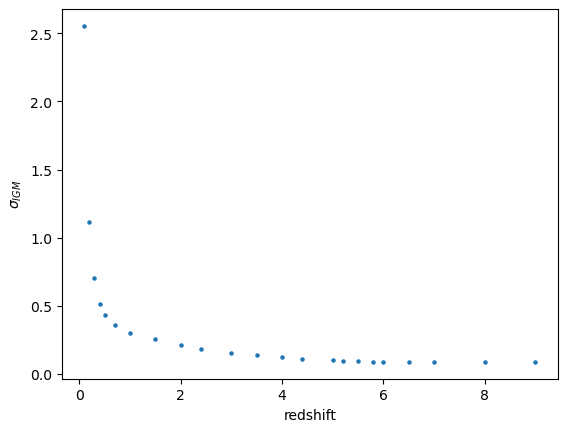

In [35]:
plt.scatter(df['z'],df['sigma'],s=5)
plt.xlabel('redshift')
plt.ylabel('$\sigma_{IGM}$')

In [4]:
def test_int(z):
    Om=OMEGA_MATTER
    def dDc(x):
        return 1/np.sqrt(Om*(1+x)**3+(1-Om))
    
    def dDM(x):
        return (1+x)/np.sqrt(Om*(1+x)**3+(1-Om))
    
    int1,_=quad(dDc, 0, z)
    int2,_=quad(dDM, 0, z)
    
    return np.sqrt(int1)/int2

In [7]:
print(test_int(0.2))

2.086459823691306


In [28]:
z_array = np.linspace(0.05, 1.6, 50)

sigma_Mz = 1/np.sqrt(z_array)
sigma_logz = 1/np.log10(1+z_array)
sigma_over_z = 1/z_array
sigma_joint_z = 1/(np.sqrt(z_array)+z_array)
sigma_joint_z_sqrd = 1/(np.sqrt(z_array+z_array**2))

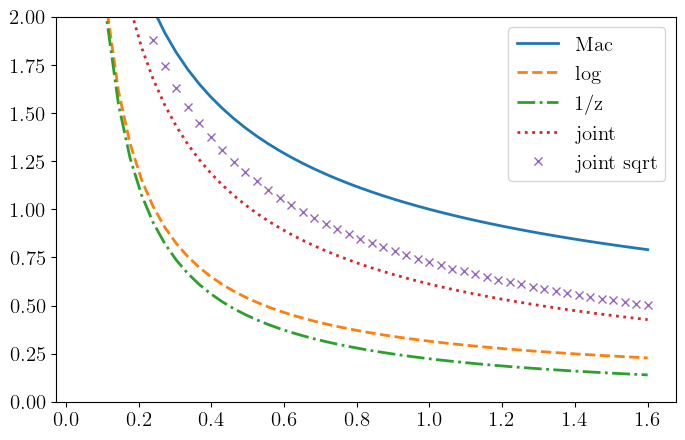

In [29]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(111)

ax1.plot(z_array, sigma_Mz, lw=2, label='Mac')
ax1.plot(z_array, sigma_Mz[0]*sigma_logz/sigma_logz[0], lw=2, ls='--', label='log')
ax1.plot(z_array, sigma_Mz[0]*sigma_over_z/sigma_over_z[0], lw=2, ls='-.', label='1/z')
ax1.plot(z_array, sigma_Mz[0]*sigma_joint_z/sigma_joint_z[0], lw=2, ls=':', label='joint')
ax1.plot(z_array, sigma_Mz[0]*sigma_joint_z_sqrd/sigma_joint_z_sqrd[0], lw=2, ls=' ', marker='x', label='joint sqrt')


# ax1.plot(z_array, sigma_logz, lw=2, ls='--')
# ax1.plot(z_array, sigma_over_z, lw=2, ls='-.')
# ax1.plot(z_array, sigma_joint_z, lw=2, ls=':')

plt.legend()
plt.ylim(0, 2)
plt.show()

In [36]:
from scipy.optimize import curve_fit

def sigma_Mac(x,a):
    return a/np.sqrt(x)

def sigma(x,a,b):
    return a/np.power(x,b)

def sigma_exp(z,a,b,c):
    return a*np.exp(-b*(z))+c

def sigma_log(z,a):
    return a/np.log(1+z)

def sigma_joint_z(z, a):
    return a/(np.sqrt(z+z**2))

def sigma_num(z,a):
    v_test_int=np.vectorize(test_int)
    return a*v_test_int(z)

x=df['z']
x=np.array(x)
y=df['sigma']
y=np.array(y)
popt_Mac, pcov_Mac = curve_fit(sigma_Mac, x, y, p0=[1.0])
popt, pcov = curve_fit(sigma, x, y, p0=[1.0,1.0])
popt_exp, pcov_exp = curve_fit(sigma_exp, x, y, p0=[1.0,1.0,1.0])
popt_log, pcov_log = curve_fit(sigma_log, x, y, p0=[1.0])
popt_num, pcov_num = curve_fit(sigma_num, x, y, p0=[0.5])
popt_joint, pcov_joint = curve_fit(sigma_joint_z, x, y, p0=[0.5])

a_fit_Mac = popt_Mac[0]
print(a_fit_Mac)
a_fit, b_fit = popt
print([a_fit,b_fit])
a_fit_exp, b_fit_exp, c_fit_exp = popt_exp
print(popt_exp)
a_fit_log = popt_log[0]
print(a_fit_log)
a_fit_num = popt_num[0]
print(a_fit_num)
a_fit_joint = popt_joint[0]
print(a_fit_joint)

x_fit=np.linspace(0.05,np.max(x),100)
y_fit_Mac = sigma_Mac(x_fit, a_fit_Mac)
y_fit = sigma(x_fit, a_fit,b_fit)
y_fit_exp = sigma_exp(x_fit, a_fit_exp,b_fit_exp, c_fit_exp)
y_fit_log = sigma_log(x_fit, a_fit_log)
y_fit_num = sigma_num(x_fit, a_fit_num)
y_fit_joint = sigma_joint_z(x_fit, a_fit_joint)
# # R²
# residuals = y - y_fit
# ss_res = np.sum(residuals**2)
# ss_tot = np.sum((y - np.mean(y))**2)
# r_squared = 1 - (ss_res / ss_tot)

y_Mac_min=sigma_Mac(x_fit,a=0.05)
y_Mac_max=sigma_Mac(x_fit,a=0.31)

0.5145463555673664
[0.2376117452027294, 1.017734610633999]
[4.84007328 7.27089734 0.15543363]
0.2238674967037722
0.5959190862802828
0.6290102121304991


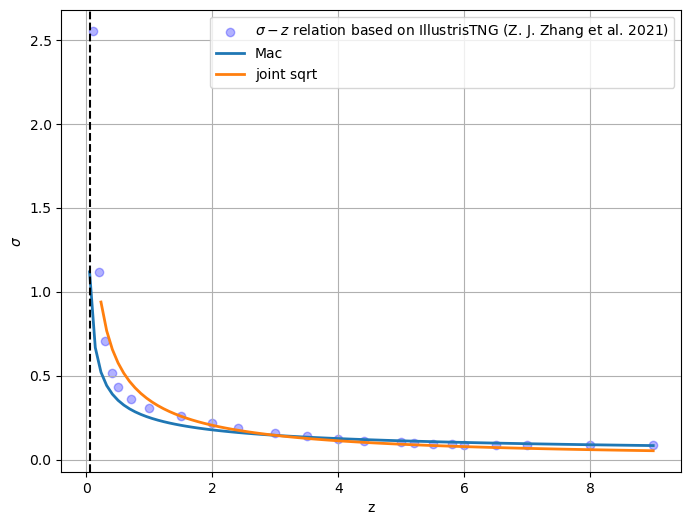

In [50]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, 
            color='blue', 
            alpha=0.3, label='$\sigma-z$ relation based on IllustrisTNG (Z. J. Zhang et al. 2021)')
# plt.plot(x_fit, y_fit_Mac, 
#          color='green', 
#          label=f'Inverse root fitting (Macquart et al. 2020): $\sigma={a_fit_Mac:.2f}/\sqrt{{z}}$')
# plt.plot(x_fit, y_Mac_min, 
#           #color='red', 
#           label='Macquart approximation: $\sigma=0.05/\sqrt{z}$')
# plt.plot(x_fit, y_Mac_max, 
#           #color='red', 
#           label='Macquart approximation: $\sigma=0.5/\sqrt{z}$')
# plt.plot(x_fit, y_fit, 
#          #color='b', 
#          label=f'Our approximation: $\sigma={a_fit:.2f}/z^{b_fit:.2f}$')
# plt.plot(x_fit, y_fit_exp, 
#          #color='g', 
#          label='Our exp approximation: $\sigma=a/(1+z)^b$')
# plt.plot(x_fit, y_fit_log, 
#          color='red', 
#          label=f'Inverse log fitting: $\sigma={a_fit_log:.2f}/log(1+z)$')
# plt.plot(x_fit, y_fit_num, 
#          color='red', 
#          label=f'num function fitting: $\sigma={a_fit_num:.2f}*num$')

# plt.plot(x_fit, y_fit_joint, lw=2, ls=' ', marker='x', label='joint sqrt')
plt.plot(x_fit, sigma_Mac(x_fit, 0.25), lw=2, label='Mac')
plt.plot(x_fit[x_fit>0.2], sigma_joint_z(x_fit[x_fit>0.2], 0.5), lw=2, label='joint sqrt')



equation = f'y = {a_fit:.2f}/√x'
#r2_text = f'R² = {r_squared:.4f}'
# plt.text(0.05, 0.95, equation + '\n' + r2_text,
#              transform=plt.gca().transAxes,
#              verticalalignment='top')

plt.axvline(x=0.05, ls='--', c='black')
plt.xlabel('z')
plt.ylabel('$\sigma$')
plt.legend()
plt.grid(True)
plt.show()

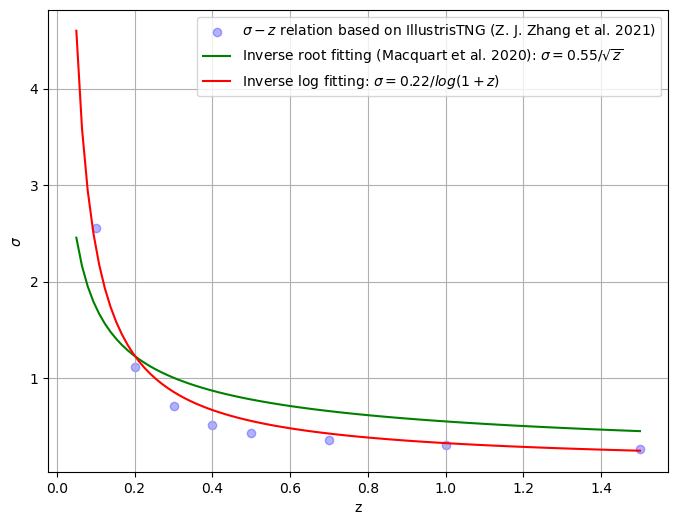

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, 
            color='blue', 
            alpha=0.3, label='$\sigma-z$ relation based on IllustrisTNG (Z. J. Zhang et al. 2021)')
plt.plot(x_fit, y_fit_Mac, 
         color='green', 
         label=f'Inverse root fitting (Macquart et al. 2020): $\sigma={a_fit_Mac:.2f}/\sqrt{{z}}$')
# plt.plot(x_fit, y_Mac_min, 
#           #color='red', 
#           label='Macquart approximation: $\sigma=0.05/\sqrt{z}$')
# plt.plot(x_fit, y_Mac_max, 
#           #color='red', 
#           label='Macquart approximation: $\sigma=0.5/\sqrt{z}$')
# plt.plot(x_fit, y_fit, 
#          #color='b', 
#          label='Our approximation: $\sigma=a/(1+z)^b$')
# plt.plot(x_fit, y_fit_exp, 
#          #color='g', 
#          label='Our exp approximation: $\sigma=a/(1+z)^b$')
plt.plot(x_fit, y_fit_log, 
         color='red', 
         label=f'Inverse log fitting: $\sigma={a_fit_log:.2f}/log(1+z)$')

equation = f'y = {a_fit:.2f}/√x'
#r2_text = f'R² = {r_squared:.4f}'
# plt.text(0.05, 0.95, equation + '\n' + r2_text,
#              transform=plt.gca().transAxes,
#              verticalalignment='top')
    
plt.xlabel('z')
plt.ylabel('$\sigma$')
plt.legend()
plt.grid(True)
plt.show()